<a href="https://colab.research.google.com/github/diseasemodeling/MIE_525_625/blob/main/A1_Graded/Graded_A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIE 625/525 ASSIGNMENT 1:
This notebook trains a XGBoost classifier for nutrition insecurity. It is one model out of 6 models from Eden Vachtel's Honors thesis.

GOAL: Fit a model to predict nutrition security. Analyze feature importance.

TYPICAL MODELING STEPS:
* A typical modeling workflow includes: Data handling and processing --> model training --> output analysis
* Data handling and processing, and model output analysis are the most critical components of machine learing project. Model training is the most simple and straightforward, once we identify the right model, as there are well developed libraries and packages.

THIS NOTEBOOK /SELF-REVIEW:
* This notebook does the necessary data handling and processing. I expect you to review it and understand what is being done. You can use AI to understand any Python code sections that are new to you.
* It also evaluates model outputs using certain metrics, that should also be reviewed. For this, instead of AI use trustable sources (human generated tutorials, wikipedia, etc., as these are standar metrics you shouldnt have trouble finding sources).

ASSIGNMENT QUESTIONS:

1.   Self-study questions
  * What is z-score and why it is necessary?
  * How to handle missing data?
  * Describe: F1 score, precision-recall curve, receiving operator curve (ROC), area under curve
  * What is class imbalance?
  * Why is precision-recall curve preferred to ROC for a dataset with class imbalance?
2.  TRAIN a NEURAL NETWORK classifier and analyze outputs
  * TRain a MLP CLASSIFIER- to classify nutrition security.
  * APPLY SHAP for feature importance.
  * Write a description
    * Analyzing the performance of MLP
    * Comparing MLP performance with XGBoost
  * Write a description
    * Explain the MLP model findings (using SHAP)
    * Compare with XGBoost
3. Train a NEURAL NETWORK to predict HEI and analyze what influences HEI
* HEI: health-eating index is a continuous variable, taking values between 0-100; higher the value, better the diet quality of that individual.
* Evaluate feature importance to determine what influences diet quality (make distintinstion causality v association)
* To separate out analysis from people who are food secure v. not, you can train two separate models.  

MIE 625 questions (optional for MIE 525)

4. Suppose our interest is to determine what fraction of Metabolic Syndromes (coded as MetS_Bin) can be prevented if we reduce nutrition insecurity, say by 25%, 50%, 75%, etc. Modify your model to do that. (Pointers: first determine what response and independent features to use, and how to do this counterfactual analysis; while 'food security' is well defined, 'nutrition security' is not. So base your model choice on rationaility; also consider multicollinearity between features)




#---
### NOTEBOOK AUTHOR: Eden Vachtel, Honors Thesis, 2025-26
#---
Advisors: Chaitra Gopalappa, Qian Zhao, Kalpana Poudel-Tandukar, Eleni Christofa

Funding: NSF # 1915481, PI: Chaitra Gopalappa

Resources: NHANES dataset and dictionary https://wwwn.cdc.gov/nchs/nhanes/search/default.aspx

## ABOUT DATASET
This notebook directly reads in "./NHANES_merged.parquet". The parquet file was created by merging NHANES Datasets, specifically, NHANES 2017-March 2020 pre-pandemic cycle.

CREATING YOUR OWN merged dataframe (parquet file):
* For this assignment you are not required to gather additional data, but you are welcome to.
* Data Download from CDC portal: https://wwwn.cdc.gov/nchs/nhanes/
  * To Download a file: Find your specific dataset, then right-click the data link (saved in SAS XPT transport format) and select Save link as to store the .xpt file locally.
  * Merge dataframe using python script (reach out to me and I can share it with you)


In [ ]:
# Run this only the first time you run this code.
#!pip install "xgboost>=1.7.1,<2.0.0" "shap>=0.41.0" "numpy<2" "pandas<2.2" "scikit-learn" "matplotlib"

# THIS NOTEBOOK: Trains a XGBoost classifier

Response variable: NutritionSecure_bin created uses self-reported food security and diet quality:  
1 = Food secure (FoodSecure_bin==1) AND Good diet (DBQ700 in {1,2,3})  
0 = Any other combination (food insecure or poor diet)  
#------

In [ ]:
import os
import re
from functools import reduce

#import gcsfs
#import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, make_scorer, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb
import shap
import matplotlib.pyplot as plt

SEED = 42
TEST_SIZE = 0.20
MISSING_CODES = {7, 9, 77, 99, 777, 999, 997, 9997, 9999}

OUT_DIR = "./nhanes_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# Binary tuning helpers
# =========================

f1_macro_scorer = make_scorer(f1_score, average="macro")
balanced_acc_scorer = make_scorer(balanced_accuracy_score)

def make_balanced_sample_weights(y):
    """
    Create per-row sample weights from inverse class frequency.
    Works for binary targets coded 0/1.
    """
    classes = np.sort(np.unique(y))
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y
    )
    class_weight_dict = dict(zip(classes, class_weights))
    sample_weights = y.map(class_weight_dict).astype(float)
    return class_weight_dict, sample_weights



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 MB 3.5 MB/s eta 0:00:00


In [ ]:
# Load merged NHANES dataset
merged = pd.read_parquet("./NHANES_merged.parquet")

print("Merged shape:", merged.shape)
print("Number of columns:", merged.shape[1])
assert "SEQN" in merged.columns

Merged shape: (32962, 630)
Number of columns: 630


### Calculate Healthy Eating Index (HEI) using dietary recall variables

In [ ]:
# =========================
# HEI-2020 (Day 1, Day 2, Avg) feature engineering
# Paste AFTER missing-code replacement (np.nan) section
# =========================

def _clamp01(x):
    return np.minimum(np.maximum(x, 0.0), 1.0)

def hei_adequacy(density, max_points, standard_max):
    """
    Higher is better. 0 at 0 intake; max_points at >= standard_max.
    """
    return max_points * _clamp01(density / standard_max)

def hei_moderation(density, max_points, standard_max_good, standard_min_zero):
    """
    Lower is better. max_points at <= standard_max_good; 0 at >= standard_min_zero.
    Linear in between.
    """
    denom = (standard_min_zero - standard_max_good)
    with np.errstate(divide="ignore", invalid="ignore"):
        frac = (standard_min_zero - density) / denom
    return max_points * _clamp01(frac)

def compute_hei2020_for_day(df, day_prefix="DR1"):
    """
    Computes HEI-2020 component + total score for a given day.
    Requires NHANES nutrient vars (kcal, sodium mg, satfat g, mufat g, pufat g, reliability flag)
    and FPED vars for that day (fruit/veg/grains/dairy/protein/add_sugars, etc.).
    """
    # ---- Nutrients (NHANES) ----
    kcal = pd.to_numeric(df.get(f"{day_prefix}TKCAL"), errors="coerce")
    sod_mg = pd.to_numeric(df.get(f"{day_prefix}TSODI"), errors="coerce")  # mg
    sfa_g  = pd.to_numeric(df.get(f"{day_prefix}TSFAT"), errors="coerce")  # g
    mufa_g = pd.to_numeric(df.get(f"{day_prefix}TMFAT"), errors="coerce")  # g
    pufa_g = pd.to_numeric(df.get(f"{day_prefix}TPFAT"), errors="coerce")  # g
    reliab = pd.to_numeric(df.get(f"{day_prefix}DRSTZ"), errors="coerce")  # 1 = reliable

    # ---- FPED totals (NHANES-style names like DR1T_*) ----
    # If your FPED datasets came through the merge, these should exist on df already.
    f_total      = pd.to_numeric(df.get(f"{day_prefix}T_F_TOTAL"), errors="coerce")
    f_citmlb     = pd.to_numeric(df.get(f"{day_prefix}T_F_CITMLB"), errors="coerce")
    f_other      = pd.to_numeric(df.get(f"{day_prefix}T_F_OTHER"), errors="coerce")
    v_total      = pd.to_numeric(df.get(f"{day_prefix}T_V_TOTAL"), errors="coerce")
    v_drkgr      = pd.to_numeric(df.get(f"{day_prefix}T_V_DRKGR"), errors="coerce")
    v_legumes    = pd.to_numeric(df.get(f"{day_prefix}T_V_LEGUMES"), errors="coerce")

    g_whole      = pd.to_numeric(df.get(f"{day_prefix}T_G_WHOLE"), errors="coerce")
    g_refined    = pd.to_numeric(df.get(f"{day_prefix}T_G_REFINED"), errors="coerce")

    d_total      = pd.to_numeric(df.get(f"{day_prefix}T_D_TOTAL"), errors="coerce")

    pf_mps       = pd.to_numeric(df.get(f"{day_prefix}T_PF_MPS_TOTAL"), errors="coerce")
    pf_eggs      = pd.to_numeric(df.get(f"{day_prefix}T_PF_EGGS"), errors="coerce")
    pf_nuts      = pd.to_numeric(df.get(f"{day_prefix}T_PF_NUTSDS"), errors="coerce")
    pf_soy       = pd.to_numeric(df.get(f"{day_prefix}T_PF_SOY"), errors="coerce")
    pf_legumes   = pd.to_numeric(df.get(f"{day_prefix}T_PF_LEGUMES"), errors="coerce")

    pf_sea_hi    = pd.to_numeric(df.get(f"{day_prefix}T_PF_SEAFD_HI"), errors="coerce")
    pf_sea_low   = pd.to_numeric(df.get(f"{day_prefix}T_PF_SEAFD_LOW"), errors="coerce")

    add_sug_tsp  = pd.to_numeric(df.get(f"{day_prefix}T_ADD_SUGARS"), errors="coerce")  # tsp equiv

    # ---- Derived FPED combos (matching your SAS logic) ----
    fwholefrt = f_citmlb + f_other
    vtotalleg = v_total + v_legumes
    vdrkgrleg = v_drkgr + v_legumes

    pfallprotleg = pf_mps + pf_eggs + pf_nuts + pf_soy + pf_legumes
    pfseaplantleg = pf_sea_hi + pf_sea_low + pf_nuts + pf_soy + pf_legumes

    # ---- Guardrails ----
    # Only compute score when reliable and kcal > 0
    valid = (reliab == 1) & (kcal > 0)
    # density per 1000 kcal helper
    with np.errstate(divide="ignore", invalid="ignore"):
        per1000 = 1000.0 / kcal

    # ---- HEI densities / ratios ----
    total_fruit_den   = f_total * per1000
    whole_fruit_den   = fwholefrt * per1000
    total_veg_den     = vtotalleg * per1000
    greens_beans_den  = vdrkgrleg * per1000
    whole_grain_den   = g_whole * per1000
    dairy_den         = d_total * per1000
    total_prot_den    = pfallprotleg * per1000
    seaplant_den      = pfseaplantleg * per1000
    refined_grain_den = g_refined * per1000

    # sodium: mg -> g, then g per 1000 kcal
    sodium_g_den = (sod_mg / 1000.0) * per1000

    # saturated fat % energy: (g * 9) / kcal * 100
    satfat_pct = (sfa_g * 9.0) / kcal * 100.0

    # added sugars % energy: tsp -> kcal using 16 kcal per tsp, then /kcal * 100
    addsug_pct = (add_sug_tsp * 16.0) / kcal * 100.0

    # fatty acid ratio: (MUFA+PUFA)/SFA
    with np.errstate(divide="ignore", invalid="ignore"):
        fatty_acid_ratio = (mufa_g + pufa_g) / sfa_g

    # ---- Component scores (HEI-2020 for age 2+) ----
    c1_total_fruit   = hei_adequacy(total_fruit_den,   5, 0.8)
    c2_whole_fruit   = hei_adequacy(whole_fruit_den,   5, 0.4)
    c3_total_veg     = hei_adequacy(total_veg_den,     5, 1.1)
    c4_greens_beans  = hei_adequacy(greens_beans_den,  5, 0.2)
    c5_whole_grains  = hei_adequacy(whole_grain_den,  10, 1.5)
    c6_dairy         = hei_adequacy(dairy_den,        10, 1.3)
    c7_total_protein = hei_adequacy(total_prot_den,    5, 2.5)
    c8_seaplant      = hei_adequacy(seaplant_den,      5, 0.8)

    c9_fatty_acids   = hei_adequacy(fatty_acid_ratio, 10, 2.5)  # max at >=2.5
    # BUT for this component, 0 at <=1.2 (so we should do linear between 1.2 and 2.5)
    # Convert to proper moderation-like scale: score 0 at 1.2, 10 at 2.5
    with np.errstate(divide="ignore", invalid="ignore"):
        c9_fatty_acids = 10.0 * _clamp01((fatty_acid_ratio - 1.2) / (2.5 - 1.2))

    c10_sodium       = hei_moderation(sodium_g_den,    10, 1.1, 2.0)
    c11_refined_gr   = hei_moderation(refined_grain_den, 10, 1.8, 4.3)
    c12_satfat       = hei_moderation(satfat_pct,      10, 8.0, 16.0)
    c13_add_sug      = hei_moderation(addsug_pct,      10, 6.5, 26.0)

    # Total score
    total = (c1_total_fruit + c2_whole_fruit + c3_total_veg + c4_greens_beans +
             c5_whole_grains + c6_dairy + c7_total_protein + c8_seaplant +
             c9_fatty_acids + c10_sodium + c11_refined_gr + c12_satfat + c13_add_sug)

    # apply validity mask
    out = pd.DataFrame({
        "SEQN": df["SEQN"],
        f"HEI2020_{day_prefix}_TOTAL": total.where(valid, np.nan)
    }, index=df.index)

    return out

# Compute day 1 + day 2 totals
hei1 = compute_hei2020_for_day(merged, day_prefix="DR1")
hei2 = compute_hei2020_for_day(merged, day_prefix="DR2")
hei1 = hei1.drop_duplicates("SEQN", keep="first")
hei2 = hei2.drop_duplicates("SEQN", keep="first")
print(hei1.head())
print(hei2.head())
print(hei1.shape)
print(hei2.shape)
print(merged['SEQN'].is_unique)
print(hei1['SEQN'].is_unique)
print(hei2['SEQN'].is_unique)


merged = merged.merge(hei1, on="SEQN", how="left", validate="many_to_one").merge(hei2, on="SEQN", how="left", validate="many_to_one")

# Average across days when both exist; otherwise keep the available day
merged["HEI2020_avg_cont"] = merged[["HEI2020_DR1_TOTAL", "HEI2020_DR2_TOTAL"]].mean(axis=1, skipna=True)

# Name it like a continuous feature so your existing regex will pick it up automatically
# merged["HEI2020_avg_cont"] = merged["HEI2020_avg"]

print("HEI computed:",
      merged["HEI2020_DR1_TOTAL"].notna().sum(), "Day1;",
      merged["HEI2020_DR2_TOTAL"].notna().sum(), "Day2;",
      merged["HEI2020_avg_cont"].notna().sum(), "Avg/Single-day available.")



       SEQN  HEI2020_DR1_TOTAL
0  109263.0          38.839291
1  109264.0          58.978305
2  109265.0          46.170224
3  109266.0          65.301869
4  109267.0                NaN
       SEQN  HEI2020_DR2_TOTAL
0  109263.0          42.732765
1  109264.0          53.019289
2  109265.0          56.584370
3  109266.0          59.804294
4  109267.0                NaN
(15560, 2)
(15560, 2)
False
True
True
HEI computed: 26855 Day1; 23384 Day2; 26874 Avg/Single-day available.


### Filter out NaN's in reponse variable, Food Security and Nutrition Security.

In [ ]:
### FIlter out NaN's in reponse variable, Food Security and Nutrition Security.
print("Constructing FoodSecurity_Final and binary FoodSecure_bin...")
merged["FoodSecurity_Final"] = np.nan

if "FSDHH" in merged.columns:
    merged.loc[merged["FSDHH"].notna(), "FoodSecurity_Final"] = merged.loc[merged["FSDHH"].notna(), "FSDHH"]
if "FSDAD" in merged.columns:
    merged.loc[merged["FoodSecurity_Final"].isna() & merged["FSDAD"].notna(), "FoodSecurity_Final"] = merged.loc[merged["FoodSecurity_Final"].isna() & merged["FSDAD"].notna(), "FSDAD"]


merged = merged[merged["FoodSecurity_Final"].notna()].copy()
merged["FoodSecurity_Final"] = pd.to_numeric(merged["FoodSecurity_Final"], errors='coerce')


def fs_to_binary(x):
    if pd.isna(x):
        return np.nan
    if x in (1, 2):
        return 1
    if x in (3, 4):
        return 0
    return np.nan

merged["FoodSecure_bin"] = merged["FoodSecurity_Final"].apply(fs_to_binary)
merged = merged[merged["FoodSecure_bin"].notna()].copy()
merged["FoodSecure_bin"] = merged["FoodSecure_bin"].astype(int)
print("After FS filtering, rows:", merged.shape[0])


Constructing FoodSecurity_Final and binary FoodSecure_bin...
After FS filtering, rows: 30783


### Build Nutrition Security target from Food Security + Diet Quality (DBQ700)


In [ ]:
# =========================
# Build Nutrition Security target from Food Security + Diet Quality (DBQ700)
# NutritionSecure_bin:
#   1 = Food secure (FoodSecure_bin==1) AND Good diet (DBQ700 in {1,2,3})
#   0 = Any other combination (food insecure or poor diet)
# =========================

# Diet quality: 1=good diet, 0=poor diet
merged["DietGood_bin"] = np.nan
if "DBQ700" in merged.columns:
    dq = pd.to_numeric(merged["DBQ700"].replace(list(MISSING_CODES), np.nan), errors="coerce")
    merged.loc[dq.isin([1, 2, 3]), "DietGood_bin"] = 1  # Excellent/Very good/Good
    merged.loc[dq.isin([4, 5]), "DietGood_bin"] = 0    # Fair/Poor

# Nutrition security target: only secure if both food secure and good diet
merged["NutritionSecure_bin"] = np.nan
mask = merged["FoodSecure_bin"].notna() & merged["DietGood_bin"].notna()
merged.loc[mask, "NutritionSecure_bin"] = (
    (merged.loc[mask, "FoodSecure_bin"] == 1) & (merged.loc[mask, "DietGood_bin"] == 1)
).astype(int)

# Drop rows where we can't define the target (missing DBQ700 or missing food security)
merged = merged[merged["NutritionSecure_bin"].notna()].copy()
merged["NutritionSecure_bin"] = merged["NutritionSecure_bin"].astype(int)

print("NutritionSecure_bin rows:", merged.shape[0])
print("NutritionSecure_bin distribution:\n", merged["NutritionSecure_bin"].value_counts(normalize=True))


NutritionSecure_bin rows: 25068
NutritionSecure_bin distribution:
 NutritionSecure_bin
1    0.536102
0    0.463898
Name: proportion, dtype: float64


# Print summary statistics on response and demographics

In [ ]:
# =========================
# Dataset characteristics for thesis Table 1
# Self-rated nutrition security model analytic sample
# Add after NutritionSecure_bin is created and filtered
# =========================

# Make sure demographic summary variables exist
if "RIDAGEYR" in merged.columns and "RIDAGEYR_cont" not in merged.columns:
    merged["RIDAGEYR_cont"] = pd.to_numeric(merged["RIDAGEYR"], errors="coerce")

if "RIAGENDR" in merged.columns and "Female" not in merged.columns:
    riagendr_num = pd.to_numeric(merged["RIAGENDR"], errors="coerce")
    merged["Female"] = np.where(
        riagendr_num == 1, 0,
        np.where(riagendr_num == 2, 1, np.nan)
    )

if "INDFMPIR" in merged.columns and "INDFMPIR_cont" not in merged.columns:
    merged["INDFMPIR_cont"] = pd.to_numeric(merged["INDFMPIR"], errors="coerce")

# HEI-based nutrition security, for Table 1 comparison
HEI_CUTOFF = 60
merged["DietGood_HEI_bin"] = np.where(
    merged["HEI2020_avg_cont"] >= HEI_CUTOFF, 1,
    np.where(merged["HEI2020_avg_cont"].notna(), 0, np.nan)
)

merged["NutritionSecure_HEI_bin"] = np.where(
    (merged["FoodSecure_bin"] == 1) & (merged["DietGood_HEI_bin"] == 1), 1,
    np.where(
        merged["FoodSecure_bin"].notna() & merged["DietGood_HEI_bin"].notna(),
        0,
        np.nan
    )
)

summary = {
    "Final Sample Size": len(merged),
    "Food secure (%)": merged["FoodSecure_bin"].mean() * 100,
    "Food insecure (%)": (1 - merged["FoodSecure_bin"].mean()) * 100,
    "Nutrition secure (self-rated definition) (%)": merged["NutritionSecure_bin"].mean() * 100,
    "Nutrition secure (HEI-based definition) (%)": merged["NutritionSecure_HEI_bin"].mean() * 100,
    "Mean age (years)": merged["RIDAGEYR_cont"].mean(),
    "Female (%)": merged["Female"].mean() * 100,
    "Mean income-to-poverty ratio": merged["INDFMPIR_cont"].mean(),
    "Mean HEI score": merged["HEI2020_avg_cont"].mean()
}

summary_df = pd.DataFrame({
    "Characteristic": summary.keys(),
    "Value": summary.values()
})

summary_df["Value"] = summary_df["Value"].round(2)

print("\n=== DATASET CHARACTERISTICS FOR THESIS TABLE 1 ===")
print(summary_df.to_string(index=False))

summary_df.to_csv(
    os.path.join(OUT_DIR, "dataset_characteristics_table1_selfrated_ns_sample.csv"),
    index=False
)


=== DATASET CHARACTERISTICS FOR THESIS TABLE 1 ===
                              Characteristic    Value
                           Final Sample Size 25068.00
                             Food secure (%)    75.36
                           Food insecure (%)    24.64
Nutrition secure (self-rated definition) (%)    53.61
 Nutrition secure (HEI-based definition) (%)    17.29
                            Mean age (years)    57.61
                                  Female (%)    52.66
                Mean income-to-poverty ratio     2.49
                              Mean HEI score    50.17


# PRINT summary statistics for selected RAW NHANES / FPED  (food patterns equivalents database) VARIABLES

In [ ]:
# ============================================================
# PRINT DESCRIPTIVE SUMMARIES FOR SELECTED RAW NHANES / FPED VARIABLES
# Paste AFTER NutritionSecure_bin is created and filtered,
# but BEFORE "Binarizing & encoding variables..."
# ============================================================

print("\n" + "="*90)
print("DESCRIPTIVE SUMMARIES FOR SELECTED VARIABLES IN THE ANALYTIC SAMPLE")
print("="*90)

# -----------------------------
# Variables to summarize
# -----------------------------
requested_vars = [
    "BMXWAIST",
    "DBQ330",
    "HIQ032A",
    "DBQ301",
    "DR1T_F_TOTAL",
    "DR2T_F_TOTAL",
    "DR1T_F_CITMLB",
    "DR2T_F_CITMLB",
    "DR1T_F_OTHER",
    "DR2T_F_OTHER",
    "DR1T_V_TOTAL",
    "DR2T_V_TOTAL",
    "DR1T_V_DRKGR",
    "DR2T_V_DRKGR",
    "DR1T_V_LEGUMES",
    "DR2T_V_LEGUMES",
    "DR1T_G_WHOLE",
    "DR2T_G_WHOLE",
    "DR1T_G_REFINED",
    "DR2T_G_REFINED",
    "DR1T_D_TOTAL",
    "DR2T_D_TOTAL",
    "DR1T_PF_MPS_TOTAL",
    "DR2T_PF_MPS_TOTAL",
    "DR1T_PF_EGGS",
    "DR2T_PF_EGGS",
    "DR1T_PF_NUTSDS",
    "DR2T_PF_NUTSDS",
    "DR1T_PF_SOY",
    "DR2T_PF_SOY",
    "DR1T_PF_LEGUMES",
    "DR2T_PF_LEGUMES",
    "DR1T_PF_SEAFD_HI",
    "DR2T_PF_SEAFD_HI",
    "DR1T_PF_SEAFD_LOW",
    "DR2T_PF_SEAFD_LOW",
    "DR1T_ADD_SUGARS",
    "DR2T_ADD_SUGARS",
]

# BP variables actually used by your MetS code
bp_sys_cols = sorted([c for c in merged.columns if c.startswith("BPXSY")])
bp_dia_cols = sorted([c for c in merged.columns if c.startswith("BPXDI")])

vars_to_summarize = []
vars_to_summarize.extend([v for v in requested_vars if v in merged.columns])
vars_to_summarize.extend(bp_sys_cols)
vars_to_summarize.extend(bp_dia_cols)
vars_to_summarize = list(dict.fromkeys(vars_to_summarize))  # remove duplicates, keep order

print("\nVariables found for summary:")
for v in vars_to_summarize:
    print(" -", v)

# -----------------------------
# Descriptions
# -----------------------------
var_descriptions = {
    "BMXWAIST": "Waist Circumference (cm)",
    "DBQ330": "Number of meals not home prepared in past 7 days",
    "HIQ032A": "Covered by private health insurance",
    "DBQ301": "Are you on any kind of diet, either to lose weight or for some other health-related reason?",

    "DR1T_F_TOTAL": "Total fruit (cup equivalents), Day 1",
    "DR2T_F_TOTAL": "Total fruit (cup equivalents), Day 2",
    "DR1T_F_CITMLB": "Citrus, melons, and berries (cup equivalents), Day 1",
    "DR2T_F_CITMLB": "Citrus, melons, and berries (cup equivalents), Day 2",
    "DR1T_F_OTHER": "Other fruits (cup equivalents), Day 1",
    "DR2T_F_OTHER": "Other fruits (cup equivalents), Day 2",
    "DR1T_V_TOTAL": "Total vegetables (cup equivalents), Day 1",
    "DR2T_V_TOTAL": "Total vegetables (cup equivalents), Day 2",
    "DR1T_V_DRKGR": "Dark green vegetables (cup equivalents), Day 1",
    "DR2T_V_DRKGR": "Dark green vegetables (cup equivalents), Day 2",
    "DR1T_V_LEGUMES": "Legumes (cup equivalents), Day 1",
    "DR2T_V_LEGUMES": "Legumes (cup equivalents), Day 2",
    "DR1T_G_WHOLE": "Whole grains (ounce equivalents), Day 1",
    "DR2T_G_WHOLE": "Whole grains (ounce equivalents), Day 2",
    "DR1T_G_REFINED": "Refined grains (ounce equivalents), Day 1",
    "DR2T_G_REFINED": "Refined grains (ounce equivalents), Day 2",
    "DR1T_D_TOTAL": "Total dairy (cup equivalents), Day 1",
    "DR2T_D_TOTAL": "Total dairy (cup equivalents), Day 2",
    "DR1T_PF_MPS_TOTAL": "Meat, poultry, seafood (ounce equivalents), Day 1",
    "DR2T_PF_MPS_TOTAL": "Meat, poultry, seafood (ounce equivalents), Day 2",
    "DR1T_PF_EGGS": "Eggs (ounce equivalents), Day 1",
    "DR2T_PF_EGGS": "Eggs (ounce equivalents), Day 2",
    "DR1T_PF_NUTSDS": "Nuts and seeds (ounce equivalents), Day 1",
    "DR2T_PF_NUTSDS": "Nuts and seeds (ounce equivalents), Day 2",
    "DR1T_PF_SOY": "Soy products (ounce equivalents), Day 1",
    "DR2T_PF_SOY": "Soy products (ounce equivalents), Day 2",
    "DR1T_PF_LEGUMES": "Legumes (ounce equivalents, protein foods category), Day 1",
    "DR2T_PF_LEGUMES": "Legumes (ounce equivalents, protein foods category), Day 2",
    "DR1T_PF_SEAFD_HI": "High omega-3 seafood (ounce equivalents), Day 1",
    "DR2T_PF_SEAFD_HI": "High omega-3 seafood (ounce equivalents), Day 2",
    "DR1T_PF_SEAFD_LOW": "Low omega-3 seafood (ounce equivalents), Day 1",
    "DR2T_PF_SEAFD_LOW": "Low omega-3 seafood (ounce equivalents), Day 2",
    "DR1T_ADD_SUGARS": "Added sugars (teaspoon equivalents), Day 1",
    "DR2T_ADD_SUGARS": "Added sugars (teaspoon equivalents), Day 2",
}

for c in bp_sys_cols:
    var_descriptions[c] = f"Systolic blood pressure reading ({c})"
for c in bp_dia_cols:
    var_descriptions[c] = f"Diastolic blood pressure reading ({c})"

# -----------------------------
# Which are categorical?
# -----------------------------
categorical_vars = {"DBQ330", "HIQ032A", "DBQ301"}

# -----------------------------
# Helper
# -----------------------------
def clean_series_for_summary(s):
    s = pd.to_numeric(s, errors="coerce")
    s = s.replace(list(MISSING_CODES), np.nan)
    return s

# -----------------------------
# Continuous summaries
# -----------------------------
continuous_rows = []

for v in vars_to_summarize:
    if v in categorical_vars:
        continue

    s = clean_series_for_summary(merged[v])

    continuous_rows.append({
        "NHANES Feature Name": v,
        "NHANES Feature and Code Description": var_descriptions.get(v, ""),
        "Min": s.min(skipna=True),
        "Max": s.max(skipna=True),
        "Median": s.median(skipna=True),
        "Mean": s.mean(skipna=True),
        "Standard Deviation": s.std(skipna=True),
        "Missing": int(s.isna().sum()),
        "N (non-missing)": int(s.notna().sum())
    })

continuous_summary_df = pd.DataFrame(continuous_rows)

# nicer display
if not continuous_summary_df.empty:
    for col in ["Min", "Max", "Median", "Mean", "Standard Deviation"]:
        continuous_summary_df[col] = continuous_summary_df[col].round(6)

print("\n" + "="*90)
print("CONTINUOUS VARIABLES")
print("="*90)
print(continuous_summary_df.to_string(index=False))

# -----------------------------
# Categorical summaries
# -----------------------------
categorical_code_columns = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 77, 99]
categorical_rows = []

for v in vars_to_summarize:
    if v not in categorical_vars:
        continue

    s = clean_series_for_summary(merged[v])
    counts = s.value_counts(dropna=False).to_dict()

    row = {
        "Domain": "Diet / Health / Insurance",
        "NHANES Feature Name": v,
        "NHANES Feature and Code Description": var_descriptions.get(v, "")
    }

    for code in categorical_code_columns:
        row[str(code)] = int(counts.get(code, 0))

    row["NaN"] = int(s.isna().sum())
    categorical_rows.append(row)

categorical_summary_df = pd.DataFrame(categorical_rows)

print("\n" + "="*90)
print("CATEGORICAL VARIABLES")
print("="*90)
if not categorical_summary_df.empty:
    print(categorical_summary_df.to_string(index=False))
else:
    print("No categorical variables found.")

print("\nDone printing descriptive summaries.\n")


DESCRIPTIVE SUMMARIES FOR SELECTED VARIABLES IN THE ANALYTIC SAMPLE

Variables found for summary:
 - BMXWAIST
 - DBQ330
 - HIQ032A
 - DBQ301
 - DR1T_F_TOTAL
 - DR2T_F_TOTAL
 - DR1T_F_CITMLB
 - DR2T_F_CITMLB
 - DR1T_F_OTHER
 - DR2T_F_OTHER
 - DR1T_V_TOTAL
 - DR2T_V_TOTAL
 - DR1T_V_DRKGR
 - DR2T_V_DRKGR
 - DR1T_V_LEGUMES
 - DR2T_V_LEGUMES
 - DR1T_G_WHOLE
 - DR2T_G_WHOLE
 - DR1T_G_REFINED
 - DR2T_G_REFINED
 - DR1T_D_TOTAL
 - DR2T_D_TOTAL
 - DR1T_PF_MPS_TOTAL
 - DR2T_PF_MPS_TOTAL
 - DR1T_PF_EGGS
 - DR2T_PF_EGGS
 - DR1T_PF_NUTSDS
 - DR2T_PF_NUTSDS
 - DR1T_PF_SOY
 - DR2T_PF_SOY
 - DR1T_PF_LEGUMES
 - DR2T_PF_LEGUMES
 - DR1T_PF_SEAFD_HI
 - DR2T_PF_SEAFD_HI
 - DR1T_PF_SEAFD_LOW
 - DR2T_PF_SEAFD_LOW
 - DR1T_ADD_SUGARS
 - DR2T_ADD_SUGARS

CONTINUOUS VARIABLES
NHANES Feature Name                        NHANES Feature and Code Description  Min    Max  Median       Mean  Standard Deviation  Missing  N (non-missing)
           BMXWAIST                                   Waist Circumference (cm) 56.4 

# Create Metabolic Syndrome (MetS) variable

In [ ]:
# =========================
# Metabolic Syndrome (MetS) feature engineering (ATP III-style, modified)
# Uses:
#   - waist (BMXWAIST)
#   - triglycerides (LBXTR)
#   - HDL (LBDHDD)
#   - BP: elevated mean SBP/DBP OR self-reported hypertension (BPQ020)
#         where mean SBP = average of BPXOSY1, BPXOSY2, BPXOSY3
#               mean DBP = average of BPXODI1, BPXODI2, BPXODI3
#   - glucose: elevated fasting glucose OR insulin use (DIQ050) OR diabetes yes (DIQ010)
#
# Output:
#   - MetS_bin
#   - helper flags for overlap-removal later:
#       MetS_from_obesity_bin
#       MetS_from_trig_bin
#       MetS_from_hdl_bin
#       MetS_from_bp_bin
#       MetS_from_glucose_bin
# =========================

def _num(x):
    return pd.to_numeric(x, errors="coerce")

def _exists(c):
    return c in merged.columns

# --- Sex indicator for sex-specific thresholds ---
if _exists("RIAGENDR"):
    female = merged["RIAGENDR"].replace({1: 0, 2: 1})
else:
    female = pd.Series(np.nan, index=merged.index)

mets_used = {}

# --- 1) Central obesity: waist >=102 men, >=88 women ---
if _exists("BMXWAIST") and female.notna().any():
    waist = _num(merged["BMXWAIST"])
    mets_obesity = pd.Series(
        np.where(female == 1, waist >= 88, waist >= 102),
        index=merged.index
    ).astype(float)
    mets_used["obesity"] = "BMXWAIST + RIAGENDR"
else:
    mets_obesity = pd.Series(np.nan, index=merged.index)

# --- 2) Triglycerides >=150 ---
if _exists("LBXTR"):
    trig = _num(merged["LBXTR"])
    mets_trig = (trig >= 150).astype(float)
    mets_used["triglycerides"] = "LBXTR"
else:
    mets_trig = pd.Series(np.nan, index=merged.index)

# --- 3) Low HDL: <40 men, <50 women ---
if _exists("LBDHDD") and female.notna().any():
    hdl = _num(merged["LBDHDD"])
    mets_hdl = pd.Series(
        np.where(female == 1, hdl < 50, hdl < 40),
        index=merged.index
    ).astype(float)
    mets_used["hdl"] = "LBDHDD + RIAGENDR"
else:
    mets_hdl = pd.Series(np.nan, index=merged.index)

# --- 4) Elevated BP: mean SBP >=130 OR mean DBP >=85 OR hypertension yes (BPQ020) ---
# Use the three oscillometric systolic/diastolic readings and average available values.
sys_cols = [c for c in ["BPXOSY1", "BPXOSY2", "BPXOSY3"] if _exists(c)]
dia_cols = [c for c in ["BPXODI1", "BPXODI2", "BPXODI3"] if _exists(c)]

bp_lab_flag = pd.Series(np.nan, index=merged.index)

if sys_cols and dia_cols:
    bp_sys = merged[sys_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1, skipna=True)
    bp_dia = merged[dia_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1, skipna=True)

    bp_lab_flag = ((bp_sys >= 130) | (bp_dia >= 85)).astype(float)
    mets_used["blood_pressure_lab"] = f"mean({sys_cols}) + mean({dia_cols})"


bpq020_flag = pd.Series(np.nan, index=merged.index)
if _exists("BPQ020"):
    bpq020 = _num(merged["BPQ020"])
    bpq020_flag = bpq020.replace({1: 1, 2: 0})
    mets_used["blood_pressure_self_report"] = "BPQ020"

bp_both_missing = bp_lab_flag.isna() & bpq020_flag.isna()
mets_bp = pd.Series(
    np.where(
        ~bp_both_missing,
        ((bp_lab_flag.fillna(0) == 1) | (bpq020_flag.fillna(0) == 1)).astype(float),
        np.nan
    ),
    index=merged.index
)

# --- 5) Elevated glucose: fasting glucose >=100 OR insulin use (DIQ050) OR diabetes yes (DIQ010) ---
glu_flag = pd.Series(np.nan, index=merged.index)
if _exists("LBXGLU"):
    glu = _num(merged["LBXGLU"])
    glu_flag = (glu >= 100).astype(float)
    mets_used["glucose_lab"] = "LBXGLU"

insulin_flag = pd.Series(np.nan, index=merged.index)
if _exists("DIQ050"):
    diq050 = _num(merged["DIQ050"])
    insulin_flag = diq050.replace({1: 1, 2: 0})  # 1 yes, 2 no
    mets_used["glucose_meds_proxy"] = "DIQ050 (insulin)"

diabetes_flag = pd.Series(np.nan, index=merged.index)
if _exists("DIQ010"):
    diq010 = _num(merged["DIQ010"])
    # 1 = yes, 2 = no, 3 = borderline
    diabetes_flag = diq010.replace({1: 1, 2: 0, 3: 0})
    mets_used["diabetes_self_report"] = "DIQ010"

glu_all_missing = glu_flag.isna() & insulin_flag.isna() & diabetes_flag.isna()
mets_glu = pd.Series(
    np.where(
        ~glu_all_missing,
        (
            (glu_flag.fillna(0) == 1) |
            (insulin_flag.fillna(0) == 1) |
            (diabetes_flag.fillna(0) == 1)
        ).astype(float),
        np.nan
    ),
    index=merged.index
)

# --- Combine MetS components ---
components = pd.DataFrame({
    "obesity": mets_obesity,
    "triglycerides": mets_trig,
    "hdl_low": mets_hdl,
    "bp_high_or_htn": mets_bp,
    "glucose_high_or_diabetes": mets_glu
}, index=merged.index)

crit_met = components.sum(axis=1, skipna=True)
crit_obs = components.notna().sum(axis=1)

# Pragmatic rule: define MetS if at least 3 criteria observed; positive if >=3 met
merged["MetS_bin"] = np.where(crit_obs >= 3, (crit_met >= 3).astype(int), np.nan)

# Save which criteria were contributing (for overlap-removal later)
merged["MetS_from_obesity_bin"] = np.where(merged["MetS_bin"] == 1, components["obesity"], 0)
merged["MetS_from_trig_bin"]    = np.where(merged["MetS_bin"] == 1, components["triglycerides"], 0)
merged["MetS_from_hdl_bin"]     = np.where(merged["MetS_bin"] == 1, components["hdl_low"], 0)
merged["MetS_from_bp_bin"]      = np.where(merged["MetS_bin"] == 1, components["bp_high_or_htn"], 0)
merged["MetS_from_glucose_bin"] = np.where(merged["MetS_bin"] == 1, components["glucose_high_or_diabetes"], 0)

print("MetS components used:", mets_used)
print("BP systolic columns used:", sys_cols)
print("BP diastolic columns used:", dia_cols)
print("BP lab flag non-missing:", bp_lab_flag.notna().sum())
print("MetS defined rows:", merged["MetS_bin"].notna().sum(), "of", merged.shape[0])
print("MetS prevalence among defined:", merged.loc[merged["MetS_bin"].notna(), "MetS_bin"].mean())

MetS components used: {'obesity': 'BMXWAIST + RIAGENDR', 'triglycerides': 'LBXTR', 'hdl': 'LBDHDD + RIAGENDR', 'blood_pressure_lab': "mean(['BPXOSY1', 'BPXOSY2', 'BPXOSY3']) + mean(['BPXODI1', 'BPXODI2', 'BPXODI3'])", 'blood_pressure_self_report': 'BPQ020', 'glucose_lab': 'LBXGLU', 'glucose_meds_proxy': 'DIQ050 (insulin)', 'diabetes_self_report': 'DIQ010'}
BP systolic columns used: ['BPXOSY1', 'BPXOSY2', 'BPXOSY3']
BP diastolic columns used: ['BPXODI1', 'BPXODI2', 'BPXODI3']
BP lab flag non-missing: 25068
MetS defined rows: 25068 of 25068
MetS prevalence among defined: 0.38954044997606513


# Print blood pressure summary

In [ ]:
# ============================================================
# CONTINUOUS SUMMARY FOR BLOOD PRESSURE VARIABLES
# Tries BPXSY*/BPXDI* first, then BPXOSY*/BPXODI*
# ============================================================

print("\n" + "="*90)
print("BLOOD PRESSURE CONTINUOUS SUMMARIES")
print("="*90)

# First try the variable families used in your MetS code
bp_sys_cols = sorted([c for c in merged.columns if c.startswith("BPXSY")])
bp_dia_cols = sorted([c for c in merged.columns if c.startswith("BPXDI")])

bp_source = "BPXSY/BPXDI"

# If none found, fall back to oscillometric variables
if not bp_sys_cols and not bp_dia_cols:
    bp_sys_cols = sorted([c for c in merged.columns if c.startswith("BPXOSY")])
    bp_dia_cols = sorted([c for c in merged.columns if c.startswith("BPXODI")])
    bp_source = "BPXOSY/BPXODI"

bp_cols = bp_sys_cols + bp_dia_cols

print(f"BP source detected: {bp_source}")

if not bp_cols:
    print("No blood pressure columns found in merged dataset.")
    print("Columns containing 'BP':")
    bp_like = [c for c in merged.columns if "BP" in c]
    for c in bp_like[:100]:
        print(" -", c)
else:
    print("BP variables found:")
    for c in bp_cols:
        print(" -", c)

    def clean_series_for_summary(s):
        s = pd.to_numeric(s, errors="coerce")
        s = s.replace(list(MISSING_CODES), np.nan)
        return s

    bp_rows = []

    for v in bp_cols:
        s = clean_series_for_summary(merged[v])

        if v.startswith("BPXSY") or v.startswith("BPXOSY"):
            desc = "Systolic blood pressure (mmHg)"
        elif v.startswith("BPXDI") or v.startswith("BPXODI"):
            desc = "Diastolic blood pressure (mmHg)"
        else:
            desc = "Blood pressure"

        bp_rows.append({
            "NHANES Feature Name": v,
            "NHANES Feature and Code Description": desc,
            "Min": s.min(skipna=True),
            "Max": s.max(skipna=True),
            "Median": s.median(skipna=True),
            "Mean": s.mean(skipna=True),
            "Standard Deviation": s.std(skipna=True),
            "Missing": int(s.isna().sum()),
            "N (non-missing)": int(s.notna().sum())
        })

    bp_summary_df = pd.DataFrame(bp_rows)

    if not bp_summary_df.empty:
        for col in ["Min", "Max", "Median", "Mean", "Standard Deviation"]:
            bp_summary_df[col] = bp_summary_df[col].round(6)

        print("\n" + "="*90)
        print("BLOOD PRESSURE SUMMARY TABLE")
        print("="*90)
        print(bp_summary_df.to_string(index=False))
    else:
        print("BP summary table is empty after processing.")

print("\nDone.\n")


BLOOD PRESSURE CONTINUOUS SUMMARIES
BP source detected: BPXOSY/BPXODI
BP variables found:
 - BPXOSY1
 - BPXOSY2
 - BPXOSY3
 - BPXODI1
 - BPXODI2
 - BPXODI3

BLOOD PRESSURE SUMMARY TABLE
NHANES Feature Name NHANES Feature and Code Description  Min   Max  Median       Mean  Standard Deviation  Missing  N (non-missing)
            BPXOSY1      Systolic blood pressure (mmHg) 66.0 225.0   125.0 127.792997           21.242859     4276            20792
            BPXOSY2      Systolic blood pressure (mmHg) 54.0 222.0   125.0 127.424534           20.832270     4297            20771
            BPXOSY3      Systolic blood pressure (mmHg) 60.0 220.0   124.0 127.147518           20.667735     4440            20628
            BPXODI1     Diastolic blood pressure (mmHg) 36.0 151.0    73.0  73.860455           12.208395     4752            20316
            BPXODI2     Diastolic blood pressure (mmHg) 31.0 146.0    72.0  73.176679           12.159638     4760            20308
            BPXODI3  

In [ ]:
print("BPXSY columns:", [c for c in merged.columns if c.startswith("BPXSY")])
print("BPXDI columns:", [c for c in merged.columns if c.startswith("BPXDI")])
print("BPXOSY columns:", [c for c in merged.columns if c.startswith("BPXOSY")])
print("BPXODI columns:", [c for c in merged.columns if c.startswith("BPXODI")])

BPXSY columns: []
BPXDI columns: []
BPXOSY columns: ['BPXOSY1', 'BPXOSY2', 'BPXOSY3']
BPXODI columns: ['BPXODI1', 'BPXODI2', 'BPXODI3']


In [ ]:


print("Binarizing & encoding variables...")
def binarize_yes_no(series, yes_codes={1}, no_codes={2}, keep_na_for_unknown=False):
    """Return series mapped to {1,0} where yes_codes -> 1, no_codes -> 0.
       If keep_na_for_unknown is False, unknown (NaN) will be left as np.nan (caller decides).
    """
    s = series.copy()
    s = s.replace(list(yes_codes), 1)
    s = s.replace(list(no_codes), 0)

    return s


if "DIQ010" in merged.columns:
    diq010_num = pd.to_numeric(merged["DIQ010"], errors="coerce")

    merged["DIQ010_Yes"] = np.where(
        diq010_num == 1, 1,
        np.where(diq010_num == 2, 0, np.nan)
    )

    merged["DIQ010_Borderline"] = np.where(
        diq010_num == 3, 1,
        np.where(diq010_num.isin([1, 2]), 0, np.nan)
    )

binary_health_vars = [
    "DIQ050", "DIQ160",
    "BPQ020", "BPQ080",
    "MCQ010", "MCQ053",
    "MCQ160b", "MCQ160c", "MCQ160d", "MCQ160e", "MCQ160f", "MCQ160l", "MCQ160p",
    "KIQ022",
    "SMQ020", "PAQ650", "OCQ210",
    "HIQ011", "HUQ090",

    "DBQ301", "DBQ330"
]

for c in binary_health_vars:
    if c in merged.columns:
        merged[c + "_bin"] = binarize_yes_no(merged[c], yes_codes={1}, no_codes={2})

Binarizing & encoding variables...


# Make binary variable for health insurance, public v private

In [ ]:
#for c in [col for col in merged.columns if col.startswith("HIQ032")]:
#    ser = merged[c].copy().replace(list(MISSING_CODES), np.nan)
#    merged[c + "_bin"] = np.where(ser.notna(), 1, np.nan)

# =========================
# Combine HIQ032* variables into one StateSponsoredHI_bin
# 1 = at least one state-sponsored insurance type selected/present
# 0 = none selected among available HIQ032 variables
# NaN = all HIQ032 variables missing
# =========================

state_hi_cols = ["HIQ032B", "HIQ032C", "HIQ032D", "HIQ032E", "HIQ032H"]
state_hi_cols = [c for c in state_hi_cols if c in merged.columns]

if state_hi_cols:
    hiq_state = merged[state_hi_cols].copy()

    # replace NHANES-style missing codes with NaN
    for c in state_hi_cols:
        hiq_state[c] = hiq_state[c].replace(list(MISSING_CODES), np.nan)

    # if any of the listed state-sponsored insurance fields is non-missing, mark as 1
    any_present = hiq_state.notna().any(axis=1)
    all_missing = hiq_state.isna().all(axis=1)

    merged["StateSponsoredHI_bin"] = np.where(any_present, 1, np.nan)
    merged.loc[~all_missing & ~any_present, "StateSponsoredHI_bin"] = 0

    print("Created StateSponsoredHI_bin from:", state_hi_cols)
else:
    print("No specified HIQ032 state-sponsored insurance columns found.")


Created StateSponsoredHI_bin from: ['HIQ032B', 'HIQ032C', 'HIQ032D', 'HIQ032E', 'HIQ032H']


In [ ]:
for ord_col in ["HUD062", "DMDEDUC2", "HUQ010", "OHQ845"]:
    if ord_col in merged.columns:
        merged[ord_col + "_ord"] = pd.to_numeric(merged[ord_col], errors="coerce")

if "RIDAGEYR" in merged.columns:
    merged["RIDAGEYR_cont"] = pd.to_numeric(merged["RIDAGEYR"], errors="coerce")

if "RIAGENDR" in merged.columns:
    riagendr_num = pd.to_numeric(merged["RIAGENDR"], errors="coerce")
    merged["Female"] = np.where(
        riagendr_num == 1, 0,
        np.where(riagendr_num == 2, 1, np.nan)
    )

# Make binary variables for Race (White, non-White), and Ethnicity (Hispanic, non-Hispanic)

In [ ]:
#Creating Hispanic and White binary variables

if "RIDRETH3" in merged.columns:
    ridreth3 = pd.to_numeric(merged["RIDRETH3"], errors="coerce")

    merged["Hispanic_bin"] = np.where(
        ridreth3.isin([1, 2]), 1,
        np.where(ridreth3.notna(), 0, np.nan)
    )

    merged["White_bin"] = np.where(
        ridreth3 == 3, 1,
        np.where(ridreth3.notna(), 0, np.nan)
    )

In [ ]:
if "DMDMARTZ" in merged.columns:
    merged = pd.get_dummies(merged, columns=["DMDMARTZ"], prefix="Marital", dummy_na=False)
if "INDFMPIR" in merged.columns:
    merged["INDFMPIR_cont"] = pd.to_numeric(merged["INDFMPIR"], errors="coerce")

# Remove overlapping MetS contributors from feature set for people with MetS

In [ ]:
# =========================
# Remove overlapping MetS contributors from feature set for people with MetS
# This prevents double-counting component conditions alongside MetS_bin
# =========================

if "MetS_bin" in merged.columns:
    mets_pos = merged["MetS_bin"] == 1

    # Remove hypertension-related feature if it contributed to MetS
    if "BPQ020_bin" in merged.columns and "MetS_from_bp_bin" in merged.columns:
        merged.loc[mets_pos & (merged["MetS_from_bp_bin"] == 1), "BPQ020_bin"] = 0

    # Remove diabetes-related feature if it contributed to MetS
    if "DIQ010_Yes" in merged.columns and "MetS_from_glucose_bin" in merged.columns:
        merged.loc[mets_pos & (merged["MetS_from_glucose_bin"] == 1), "DIQ010_Yes"] = 0

    # Also remove insulin-use proxy if it contributed to MetS glucose criterion
    if "DIQ050_bin" in merged.columns and "MetS_from_glucose_bin" in merged.columns:
        merged.loc[mets_pos & (merged["MetS_from_glucose_bin"] == 1), "DIQ050_bin"] = 0

    print("Applied MetS overlap-removal to BPQ020_bin / DIQ010_Yes / DIQ050_bin where relevant.")


Applied MetS overlap-removal to BPQ020_bin / DIQ010_Yes / DIQ050_bin where relevant.


# Combine Dietary recall day 1 and day 2 (DR1 and DR2)  variables

In [ ]:
print("Creating DR1+DR2 total variables where applicable...")
cols = set(merged.columns)
dr1_cols = [c for c in cols if c.startswith("DR1")]
dr2_cols = [c for c in cols if c.startswith("DR2")]
paired_suffixes = [c[3:] for c in dr1_cols if ("DR2" + c[3:]) in cols]

for suf in paired_suffixes:
    c1 = "DR1" + suf
    c2 = "DR2" + suf
    merged["Total_" + suf] = pd.to_numeric(merged.get(c1), errors='coerce') + pd.to_numeric(merged.get(c2), errors='coerce')


print("Selecting numeric columns for modeling...")

#removed Dietary totals from independant variables list
#pattern = re.compile(r'(_bin$)|(_cont$)|(_ord$)|(^Total_)|(^DIQ010_)|(^RIDAGEYR_cont$)|(^INDFMPIR_cont$)|(^Female$)|(^RIDRETH3_)|(^Marital_)')
pattern = re.compile(
    r'(_bin$)|(_cont$)|(_ord$)|'
    r'(^DIQ010_)|'
    r'(^RIDAGEYR_cont$)|'
    r'(^INDFMPIR_cont$)|'
    r'(^Female$)|'
    r'(^White_bin$)|'
    r'(^Hispanic_bin$)|'
    r'(^Marital_)'
)


candidate_cols = [c for c in merged.columns if pattern.search(c)]

exclude_cols = {
    "DietGood_HEI_bin",
    "NutritionSecure_HEI_bin",
    "HEI2020_avg_cont",
    "HEI2020_DR1_TOTAL",
    "HEI2020_DR2_TOTAL",
    "DBQ700"
}

candidate_cols = [c for c in candidate_cols if c not in exclude_cols]

#candidate_cols = list(dict.fromkeys(["SEQN", "FoodSecurity_Final", "FoodSecure_bin"] + candidate_cols))
#New candidate_cols line for nutrition security

candidate_cols = list(dict.fromkeys([
    "SEQN",
    "WTINTPRP",
    "FoodSecurity_Final",
    "FoodSecure_bin",
    "DietGood_bin",
    "NutritionSecure_bin"
] + candidate_cols))

model_df = merged[candidate_cols].copy()

# Keep only participants eligible for fasting subsample-weighted analysis
model_df["WTINTPRP"] = pd.to_numeric(model_df["WTINTPRP"], errors="coerce")
model_df = model_df[model_df["WTINTPRP"].notna() & (model_df["WTINTPRP"] > 0)].copy()

print("After fasting-weight filtering:", model_df.shape)

# Remove HEI variables from independent variables
hei_cols_to_drop = [c for c in [
    "HEI2020_avg_cont",
    "HEI2020_DR1_TOTAL",
    "HEI2020_DR2_TOTAL"
] if c in model_df.columns]

if hei_cols_to_drop:
    model_df = model_df.drop(columns=hei_cols_to_drop)
    print("Dropped HEI columns from model_df:", hei_cols_to_drop)

Creating DR1+DR2 total variables where applicable...
Selecting numeric columns for modeling...
After fasting-weight filtering: (25068, 41)


/tmp/ipykernel_1007/273741668.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["Total_" + suf] = pd.to_numeric(merged.get(c1), errors='coerce') + pd.to_numeric(merged.get(c2), errors='coerce')
/tmp/ipykernel_1007/273741668.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged["Total_" + suf] = pd.to_numeric(merged.get(c1), errors='coerce') + pd.to_numeric(merged.get(c2), errors='coerce')
/tmp/ipykernel_1007/273741668.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

# Remove variables that should not be considered in model

In [ ]:
# Remove any old individual HIQ032 binary variables if they exist
old_state_hi_bins = [c for c in ["HIQ032B_bin", "HIQ032C_bin", "HIQ032D_bin", "HIQ032E_bin", "HIQ032H_bin"] if c in model_df.columns]
if old_state_hi_bins:
    model_df = model_df.drop(columns=old_state_hi_bins)
    print("Dropped old individual state-sponsored insurance bins:", old_state_hi_bins)

In [ ]:
# Drop helper columns used only for overlap-removal, not for modeling
mets_helper_cols = [c for c in [
    "MetS_from_obesity_bin",
    "MetS_from_trig_bin",
    "MetS_from_hdl_bin",
    "MetS_from_bp_bin",
    "MetS_from_glucose_bin"
] if c in model_df.columns]

if mets_helper_cols:
    model_df = model_df.drop(columns=mets_helper_cols)
    print("Dropped MetS helper columns from model_df:", mets_helper_cols)

Dropped MetS helper columns from model_df: ['MetS_from_obesity_bin', 'MetS_from_trig_bin', 'MetS_from_hdl_bin', 'MetS_from_bp_bin', 'MetS_from_glucose_bin']


In [ ]:
# --- REMOVE self-rated health quality feature ---
if "HUQ010_ord" in model_df.columns:
    model_df = model_df.drop(columns=["HUQ010_ord"])
    print("Dropped HUQ010_ord from model_df.")

model_df = model_df.dropna(axis=1, how="all")
print("Model dataframe shape (pre-clean):", model_df.shape)



print("Preparing X and y...")
keep_identifier = "SEQN"
if keep_identifier not in model_df.columns:
    raise RuntimeError("SEQN not present in model dataframe — aborting.")

#y = model_df["FoodSecure_bin"].astype(int)
#X = model_df.drop(columns=["FoodSecurity_Final", "FoodSecure_bin"])

#Updated x and y for nutrition security

survey_w = model_df["WTINTPRP"].astype(float)

# Target is Nutrition Security now
y = model_df["NutritionSecure_bin"].astype(int)

drop_cols = [
    "WTINTPRP",
    "FoodSecurity_Final",
    "FoodSecure_bin",

    # self-rated target variables
    "DietGood_bin",
    "NutritionSecure_bin",

    # HEI-derived variables
    "DietGood_HEI_bin",
    "NutritionSecure_HEI_bin",

    # HEI scores
    "HEI2020_avg_cont",
    "HEI2020_DR1_TOTAL",
    "HEI2020_DR2_TOTAL",

    # original self-rated diet question
    "DBQ700"
]

drop_cols = [c for c in drop_cols if c in model_df.columns]

X = model_df.drop(columns=drop_cols)



if "SEQN" in X.columns:
    X_features = X.drop(columns=["SEQN"])
else:
    X_features = X.copy()

print("X features shape:", X_features.shape)
print("Target distribution:\n", y.value_counts(normalize=True))


print("Keeping missing values as NaN (no dropping, no imputation).")

# Keep only numeric feature columns for modeling
num_feature_cols = X_features.select_dtypes(include=[np.number]).columns.tolist()
X_imp = X_features[num_feature_cols].copy()

non_numeric = [c for c in X_features.columns if c not in num_feature_cols]
if non_numeric:
    print("Dropping non-numeric columns (not used for modeling):", non_numeric)

print("X matrix shape (numeric only):", X_imp.shape)
print("Total NaNs in X:", int(X_imp.isna().sum().sum()))


Dropped HUQ010_ord from model_df.
Model dataframe shape (pre-clean): (25068, 35)
Preparing X and y...
X features shape: (25068, 29)
Target distribution:
 NutritionSecure_bin
1    0.536102
0    0.463898
Name: proportion, dtype: float64
Keeping missing values as NaN (no dropping, no imputation).
Dropping non-numeric columns (not used for modeling): ['Marital_1.0', 'Marital_2.0', 'Marital_3.0', 'Marital_77.0', 'Marital_99.0']
X matrix shape (numeric only): (25068, 24)
Total NaNs in X: 106151


# Apply z-score standardization

In [ ]:
print("Z-scoring continuous variables (NaN-safe).")

cont_pattern = re.compile(r'(_cont$)|(^RIDAGEYR_cont$)|(^INDFMPIR_cont$)|(^Total_)')
cont_cols = [c for c in X_imp.columns if cont_pattern.search(c)]

if cont_cols:
    for c in cont_cols:
        mu = X_imp[c].mean(skipna=True)
        sd = X_imp[c].std(skipna=True)
        if pd.isna(sd) or sd == 0:
            # skip constant/all-missing columns
            continue
        X_imp[c] = (X_imp[c] - mu) / sd
    print(f"Z-scored {len(cont_cols)} continuous columns (NaN-safe).")
else:
    print("No continuous columns found to z-score; skipping.")


print(merged['RIDAGEYR_cont'].head())

print(X_imp['RIDAGEYR_cont'].head())


Z-scoring continuous variables (NaN-safe).
Z-scored 2 continuous columns (NaN-safe).
3     29.0
4     21.0
5     18.0
9     49.0
10    49.0
Name: RIDAGEYR_cont, dtype: float64
3    -1.590544
4    -2.035307
5    -2.202093
9    -0.478639
10   -0.478639
Name: RIDAGEYR_cont, dtype: float64


# XGBoost Classifier
* Split to train and test variables
* Cross-validation through StratifiedKFold
* Hyperparameter tuning through random grid search

In [ ]:
print("Splitting into train/test (stratified)...")
X_train, X_test, y_train, y_test, survey_w_train, survey_w_test = train_test_split(
    X_imp,
    y,
    survey_w,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

print("\nComputing balanced class weights from y_train...")
class_weight_dict, class_weights_train = make_balanced_sample_weights(y_train)

sample_weights_train = class_weights_train * survey_w_train
sample_weights_train = sample_weights_train / sample_weights_train.mean()

print("Class weights:")
for cls, wt in class_weight_dict.items():
    print(f"  Class {cls}: {wt:.4f}")

print("\nTraining set class distribution:")
print(y_train.value_counts().sort_index())

print("\nTuning binary XGBoost classifier with RandomizedSearchCV...")

base_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=6,
    missing=np.nan,
    tree_method="hist"
)

param_dist = {
    "n_estimators": [200, 300, 500, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [3, 4, 5, 6, 8],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5, 1.0],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [1, 1.5, 2, 3, 5],
    "max_delta_step": [0, 1, 3, 5]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring=f1_macro_scorer,
    n_jobs=1,
    cv=cv,
    verbose=2,
    random_state=SEED,
    refit=True
)

search.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train
)

print("\nBest CV macro-F1:", search.best_score_)
print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

cv_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
cv_results.to_csv(
    os.path.join(OUT_DIR, "xgb_nutritionsecure_randomsearch_results.csv"),
    index=False
)
print("Saved tuning results to:",
      os.path.join(OUT_DIR, "xgb_nutritionsecure_randomsearch_results.csv"))

print("\nRefitting final model using best hyperparameters...")

best_params = search.best_params_

model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=6,
    missing=np.nan,
    tree_method="hist",
    **best_params
)

model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train
)

#joblib.dump(model, os.path.join(OUT_DIR, "xgb_nutritionsecure_tuned_model.joblib"))
#joblib.dump(search, os.path.join(OUT_DIR, "xgb_nutritionsecure_randomsearch.joblib"))

print("\n=== MODEL PERFORMANCE ===")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

macro_f1_test = f1_score(y_test, y_pred, average="macro")
weighted_f1_test = f1_score(y_test, y_pred, average="weighted")
balanced_acc_test = balanced_accuracy_score(y_test, y_pred)

print("Test Macro F1:", round(macro_f1_test, 4))
print("Test Weighted F1:", round(weighted_f1_test, 4))
print("Test Balanced Accuracy:", round(balanced_acc_test, 4))

print(classification_report(y_test, y_pred, target_names=["Nutrition Insecure (0)", "Nutrition Secure (1)"]))

try:
    auc = roc_auc_score(y_test, y_proba)
except Exception as e:
    auc = np.nan
    print("ROC-AUC error:", e)

print("ROC-AUC:", auc)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Splitting into train/test (stratified)...
Train shape: (20054, 24) Test shape: (5014, 24)

Computing balanced class weights from y_train...
Class weights:
  Class 0: 1.0778
  Class 1: 0.9327

Training set class distribution:
NutritionSecure_bin
0     9303
1    10751
Name: count, dtype: int64

Tuning binary XGBoost classifier with RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_delta_step=0, max_depth=4, min_child_weight=5, n_estimators=500, reg_alpha=0.5, reg_lambda=2, subsample=1.0; total time=   4.7s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_delta_step=0, max_depth=4, min_child_weight=5, n_estimators=500, reg_alpha=0.5, reg_lambda=2, subsample=1.0; total time=  12.7s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.01, max_delta_step=0, max_depth=4, min_child_weight=5, n_estimators=500, reg_alpha=0.5, reg_lambda=2, subsample=1.0; total time=   5.1s
[C

# Plot precision-recall curve

* For each sample, XGBoost outputs the probability that its outcome = 1
* It then applies a threshold to classify the outcome as 0 or 1, i.e.,
  * IF probability > threshold, THEN output = 1 ELSE output = 0
* Precision-recall curve is a curve of precision and recall under different values of threshold.
*  $$Precision = \frac{True\ Positives(TP)}{True\ Positives(TP)+False\ Positives(FP)}$$
$$Recall = \frac{True\ Positives(TP)}{True\ Positives(TP)+False\ Negatives(FN)}$$
* PR curves are typically plotted again a 'baseline': which is the expected precision if we were to randomly classify a sample as 0 or 1, i.e., if there are say 30% of samples with outcome 1, baseline = 30%






Plotting Precision-Recall Curve...


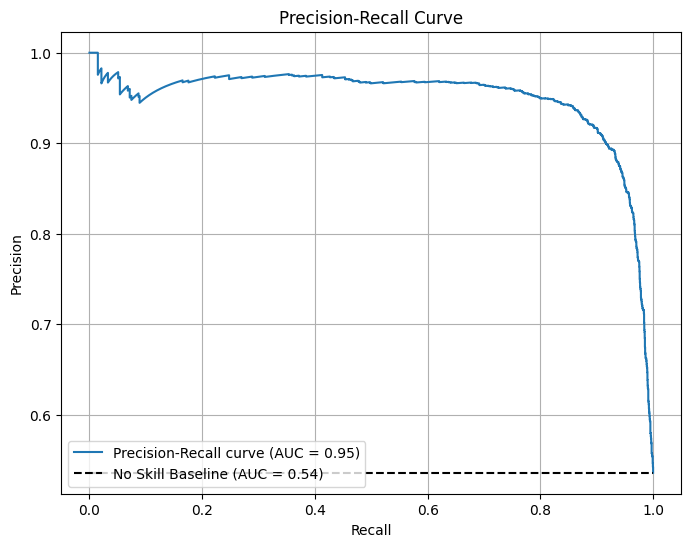

Precision-Recall AUC: 0.9497


In [ ]:
from sklearn.metrics import precision_recall_curve, auc

print("\nPlotting Precision-Recall Curve...")

# Calculate precision and recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)

# Calculate Area Under the Curve (AUC)
pr_auc = auc(recall, precision)

# Calculate the no-skill baseline (proportion of positive class)
no_skill_baseline = y_test.sum() / len(y_test)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.plot([0, 1], [no_skill_baseline, no_skill_baseline], 'k--', label=f'No Skill Baseline (AUC = {no_skill_baseline:.2f})') # Baseline
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print(f"Precision-Recall AUC: {pr_auc:.4f}")

# As there is no class imbalance, we could also look at AUC of ROC curve
* What is class imbalance?
  * Occur in applications with rare events, e.g, 5% of samples have outcome = 1, and 95% with outcome = 0. This is an imbalanced class.
    * Rare event examples: credit card fraud, disease diagnosis, equipment failure
  * Why is this important to know, and why is



Plotting ROC Curve...


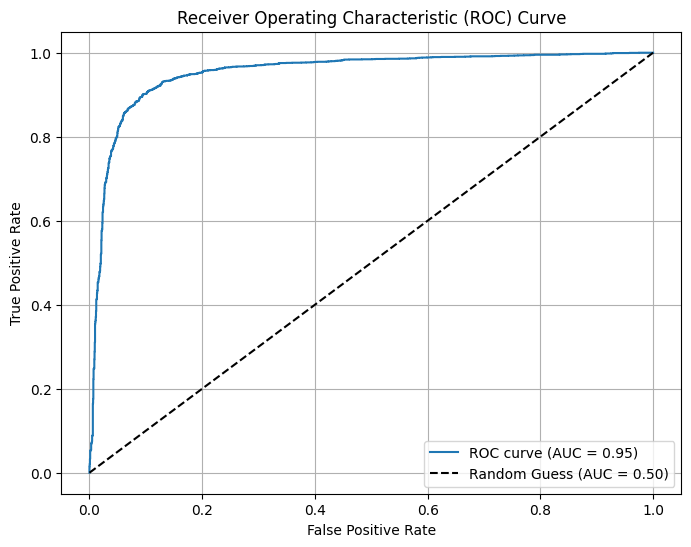

ROC AUC: 0.9527


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

print("\nPlotting ROC Curve...")

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)') # Baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

## Additionally, if our intent was forecasting or prediction, we review what is a good probability threshold for classifying future cases.

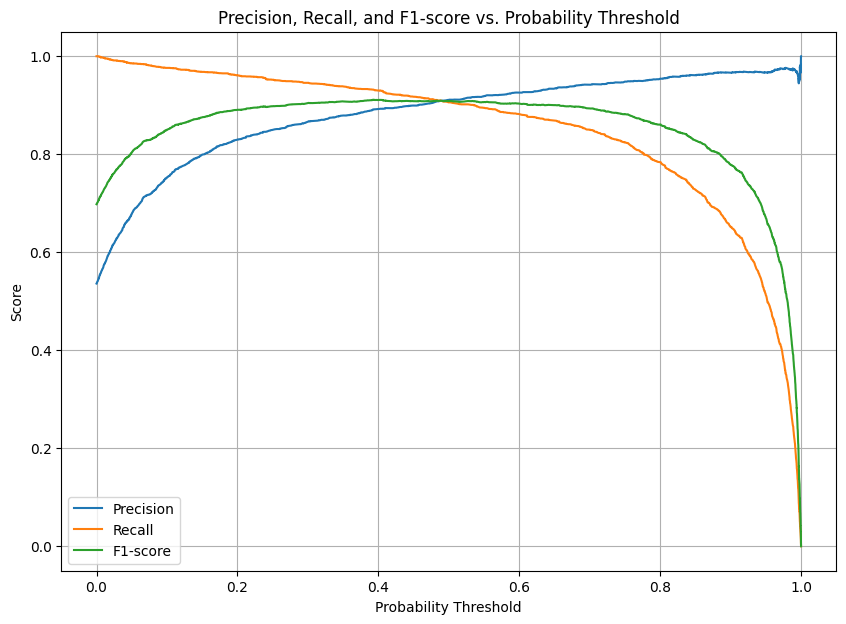

In [ ]:
# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Extend thresholds to include 0.0 to match the length of precision and recall arrays for plotting.
# precision_recall_curve returns 'thresholds' array that is one element shorter than 'precision' and 'recall'.
# The first value in 'precision' and 'recall' corresponds to an implicit threshold of 0.
thresholds_extended = np.append(0.0, thresholds)

# Calculate F1 scores
f1_scores = 2 * (precision * recall) / (precision + recall)

# Handle NaN values in F1 score where precision + recall is zero (e.g., at very high thresholds)
f1_scores = np.nan_to_num(f1_scores)

plt.figure(figsize=(10, 7))
plt.plot(thresholds_extended, precision, label='Precision')
plt.plot(thresholds_extended, recall, label='Recall')
plt.plot(thresholds_extended, f1_scores, label='F1-score')

plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-score vs. Probability Threshold')
plt.legend()
plt.grid(True)
plt.show()

# SHAP values: MEasure feature importance. Especially in this example, we are interested in understanding what features contribute to food insecurity.


Computing SHAP values...
Rendering SHAP summary plot (be sure your environment supports plotting)...


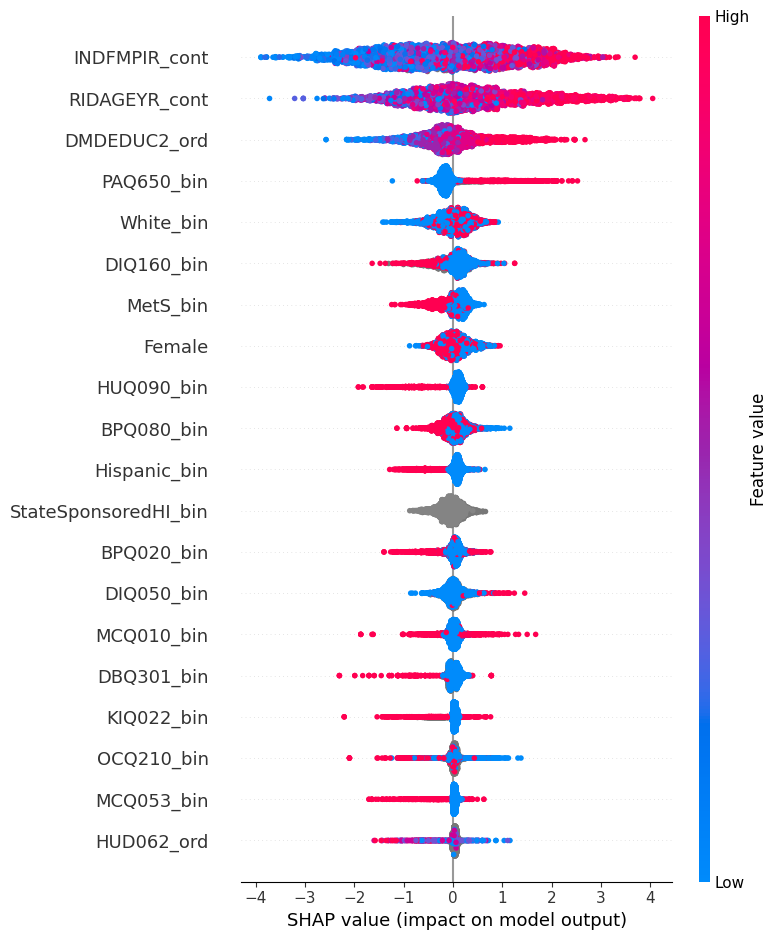

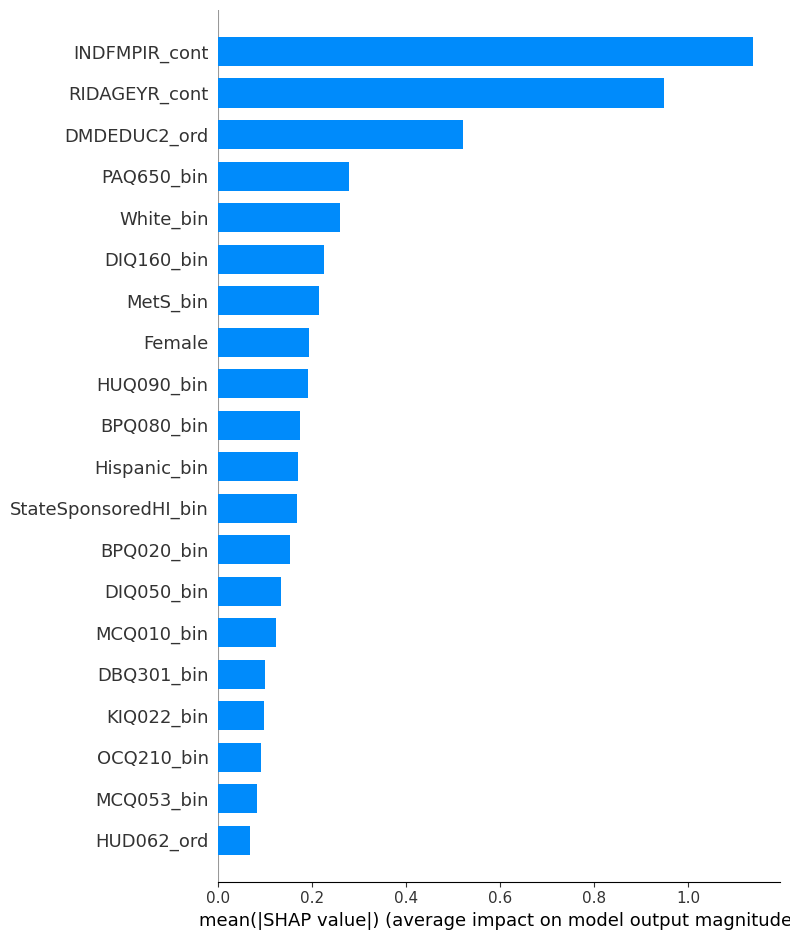

Saving SHAP importances to CSV...
Top 20 SHAP features:
                  Feature  MeanAbsSHAP
2          INDFMPIR_cont     1.138576
0          RIDAGEYR_cont     0.948597
21          DMDEDUC2_ord     0.519907
13            PAQ650_bin     0.278758
23             White_bin     0.258948
7             DIQ160_bin     0.225702
3               MetS_bin     0.214284
1                 Female     0.192583
16            HUQ090_bin     0.189876
9             BPQ080_bin     0.173345
22          Hispanic_bin     0.170286
19  StateSponsoredHI_bin     0.168127
8             BPQ020_bin     0.153339
6             DIQ050_bin     0.133279
10            MCQ010_bin     0.121591
17            DBQ301_bin     0.098838
12            KIQ022_bin     0.097846
14            OCQ210_bin     0.091350
11            MCQ053_bin     0.082809
20            HUD062_ord     0.066353
Saving cleaned dataset with SEQN to CSV...
Saved cleaned data to: ./nhanes_outputs/nhanes_cleaned_model_data.csv

Pipeline complete. Outputs in: 

In [ ]:
print("\nComputing SHAP values...")

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)


print("Rendering SHAP summary plot (be sure your environment supports plotting)...")
plt.figure(figsize=(10, 6))

try:
    shap.summary_plot(shap_values, X_test, plot_type="dot", show=True)
except Exception:

    mean_abs = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({"feature": X_test.columns, "mean_abs_shap": mean_abs})
    importance_df = importance_df.sort_values("mean_abs_shap", ascending=False).head(20)
    importance_df.plot.barh(x="feature", y="mean_abs_shap", legend=False)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


plt.figure(figsize=(8, 6))
try:
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)
except Exception:
    pass


print("Saving SHAP importances to CSV...")

if isinstance(shap_values, list):

    shap_arr = np.array(shap_values).mean(axis=0)
else:
    shap_arr = np.array(shap_values)

mean_abs_shap = np.abs(shap_arr).mean(axis=0)
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

shap_importance.to_csv(os.path.join(OUT_DIR, "nhanes_shap_feature_importance.csv"), index=False)
print("Top 20 SHAP features:\n", shap_importance.head(20))


print("Saving cleaned dataset with SEQN to CSV...")

cleaned_features = X_imp.copy()

if "SEQN" in model_df.columns:
    cleaned_df = model_df[["SEQN"]].join(cleaned_features)
else:
    cleaned_df = cleaned_features

cleaned_df["NutritionSecure_bin"] = y.values
cleaned_df.to_csv(os.path.join(OUT_DIR, "nhanes_cleaned_model_data.csv"), index=False)
print("Saved cleaned data to:", os.path.join(OUT_DIR, "nhanes_cleaned_model_data.csv"))

print("\nPipeline complete. Outputs in:", OUT_DIR)
